# Testing the draft segmented density plot (`team/new_graphics/segmented_density.py`)

This notebook exercises `make_segmented_density()`, the draft implementation of the
segmented density plot type (commonly called a "ridgeline" plot). It is **not** wired into `.plot()` yet — this is for visually checking the
draft before integration.

The segmented density plot's place in the agenda: in the default plot lookup table (DECISIONS.md,
"Decision: Default Plot Lookup Table") it is an **alternative** plot — never the
default — for the 2D discrete × continuous and continuous × discrete configurations,
at both small and large n, so at integration it will appear in the suggestion message
for those configurations (`type='segmented_density'`). The graphics plan (Phase 5) also names
density ridge plots as the view for **discrete-time continuous-state processes**: one
ridge per time point (Section 7).

**How to run:** open this notebook from the `team/new_graphics/new_graphics_demos/`
folder using the `symbulate` conda environment, then Run All.

**What to look for:**
- One small density curve ("ridge") per level of the discrete variable, stacked along
  the discrete axis with a gentle overlap; lower ridges sit in front
- Translucent fill (alpha 0.4) under a fully opaque outline
- No arguments needed beyond the data and axes: with `color` omitted, the first batch
  automatically takes the style sheet's first hue (Okabe-Ito sky blue) and a second
  call on the same axes advances to the next (orange) — the same cycle
  `get_next_color(ax)` reads, so the standalone draft and the future `.plot()`
  integration give identical colors
- All ridges in one call share a single density scale — a taller peak really is a
  taller density, so levels are directly comparable
- Baselines at the discrete-axis ticks, labeled with the level values; headroom above
  the top baseline for its ridge
- Orientation follows which variable is discrete, mirroring the segmented rug and
  mixed tile plots: discrete y → classic horizontal ridges; discrete x → flipped
- Levels too sparse for a KDE fall back to tick marks on their baseline, with a note
- A light reference grid behind the ridges on both axes: value-axis lines for reading
  the density curves (as the 1D density plot draws) and one line per discrete level
  (the segmented rug's convention)
- Axis labels "X"/"Y", title "Segmented Density Plot"

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# This notebook lives in <repo>/team/new_graphics/new_graphics_demos/.
REPO_ROOT = Path.cwd().parents[2]

# Make `import symbulate` find the dev copy in this repo (not an older
# installed copy in site-packages), and `from segmented_density import ...` find
# the draft module one folder up.
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(Path.cwd().parent))

# The draft helper and its per-plot-type constants
from segmented_density import (
    make_segmented_density,
    SEGMENTED_DENSITY_FILL_ALPHA,
    SEGMENTED_DENSITY_PEAK_SCALE,
)

# Apply the global style file (Okabe-Ito cycle, grid, spines, fonts).
# The integrated symbulate/plot.py now applies this same file at import,
# so the symbulate imports later in this notebook won't undo it.
STYLE_PATH = REPO_ROOT / "symbulate" / "symbulate.mplstyle"
plt.style.use(STYLE_PATH)

rng = np.random.default_rng(7)
print(
    f"SEGMENTED_DENSITY_FILL_ALPHA = {SEGMENTED_DENSITY_FILL_ALPHA}, "
    f"SEGMENTED_DENSITY_PEAK_SCALE = {SEGMENTED_DENSITY_PEAK_SCALE}"
)

SEGMENTED_DENSITY_FILL_ALPHA = 0.4, SEGMENTED_DENSITY_PEAK_SCALE = 1.6


## 1. The classic orientation — discrete y, continuous x

Five levels of a discrete variable on y, a continuous variable on x whose mean shifts
with the level. One horizontal ridge per level, stacked vertically: the classic
ridgeline look. The ridges are estimated over one shared, quantile-based x-range (0.1th to
99.9th percentile of the pooled values, plus padding) so an outlier can't stretch the
axis, and they share one density scale — the tallest peak reaches
`SEGMENTED_DENSITY_PEAK_SCALE` (1.6) baseline spacings and every other peak keeps its true
relative height. Where neighbors overlap, the lower (nearer) ridge is drawn in front.

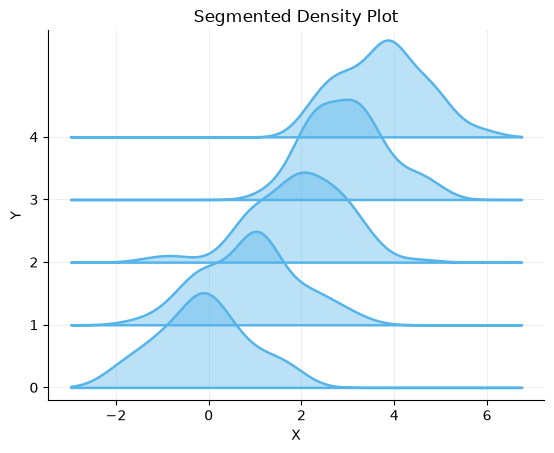

In [2]:
groups = rng.integers(0, 5, 400)            # discrete: 5 levels -> 5 ridges
values = rng.normal(0, 1, 400) + groups     # continuous, shifted by level

ax = plt.gca()
make_segmented_density(values, groups, ax)  # x continuous, y discrete; color is automatic
plt.show()  # title, axis labels, and the sky-blue color are set by make_segmented_density

## 2. Axes swapped — discrete x, continuous y

The same data passed in the other order. Because the baselines follow the discrete
axis, the ridges now stand vertically and stack horizontally, each extending to the
right of its baseline — matching how the segmented rug and mixed tile plots flip when
`x` is the discrete variable, so all views of one dataset stay consistent.

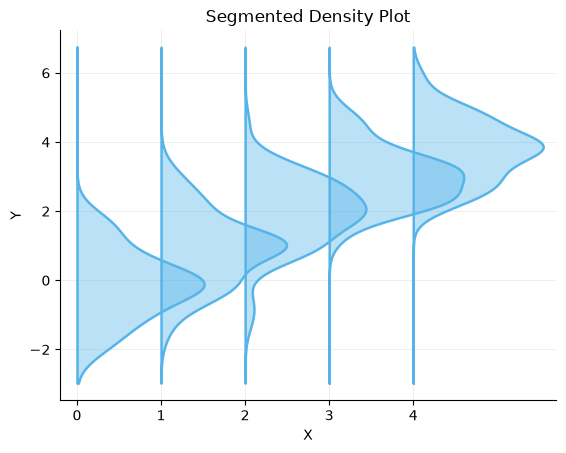

In [3]:
ax = plt.gca()
make_segmented_density(groups, values, ax)  # x discrete, y continuous
plt.show()

## 3. Options: bandwidth, fill alpha, explicit color

`bandwidth=` passes through to `scipy.stats.gaussian_kde` as `bw_method` for every
ridge (default: Scott's rule), the same option `make_density` takes. `alpha=` changes
only the fill — the outline always stays opaque so the density shape reads clearly
even where ridges overlap. An explicit `color=` overrides the automatic cycle (at
integration, `.plot()` passes `get_next_color(ax)` in through this parameter).

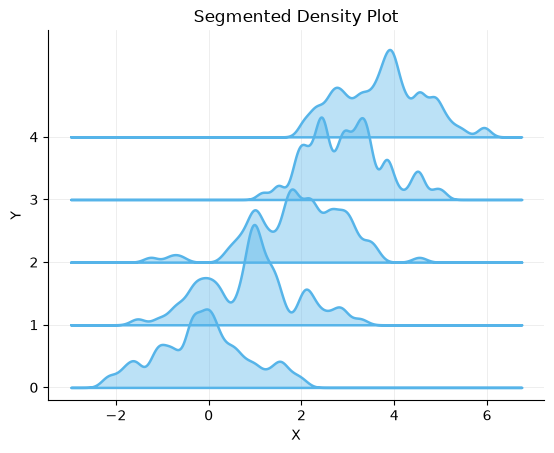

In [4]:
# A small bandwidth undersmooths -- wiggly ridges that chase the sample
ax = plt.gca()
make_segmented_density(values, groups, ax, bandwidth=0.15)
plt.show()

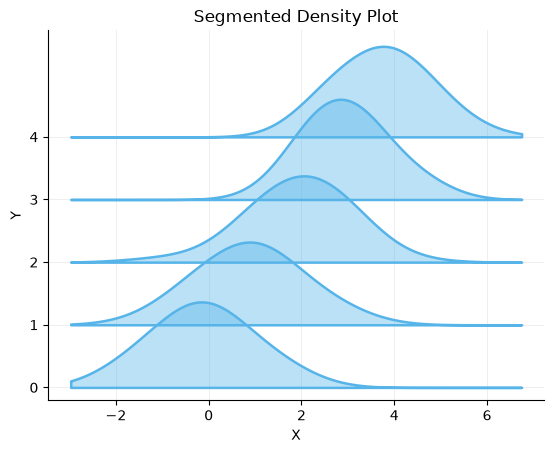

In [5]:
# A large bandwidth oversmooths -- broad, flat ridges
ax = plt.gca()
make_segmented_density(values, groups, ax, bandwidth=0.8)
plt.show()

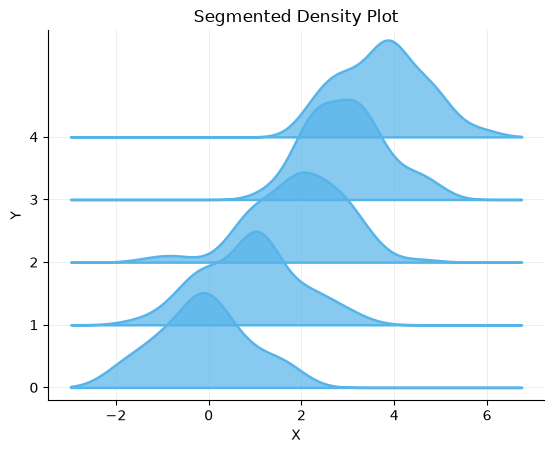

In [6]:
# Heavier fill; the outline is unchanged
ax = plt.gca()
make_segmented_density(values, groups, ax, alpha=0.7)
plt.show()

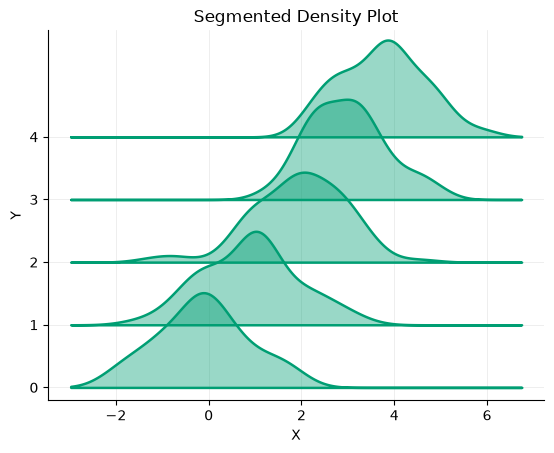

In [7]:
# Explicit color overrides the automatic cycle (Okabe-Ito green)
ax = plt.gca()
make_segmented_density(values, groups, ax, color="#009E73")
plt.show()

## 4. Sparse levels fall back to tick marks

A level with fewer than two distinct values can't support a density estimate. Rather
than failing the whole plot, that level keeps its baseline and shows its observations
as short tick marks (a tiny rug), and a note explains what happened and how to fix
it. Here level 9 has a single observation.

Note: level(s) 9 have fewer than 2 distinct values, so no density curve can be estimated for them. Their observations are drawn as tick marks on the baseline instead. Simulating more draws will fill those levels in.


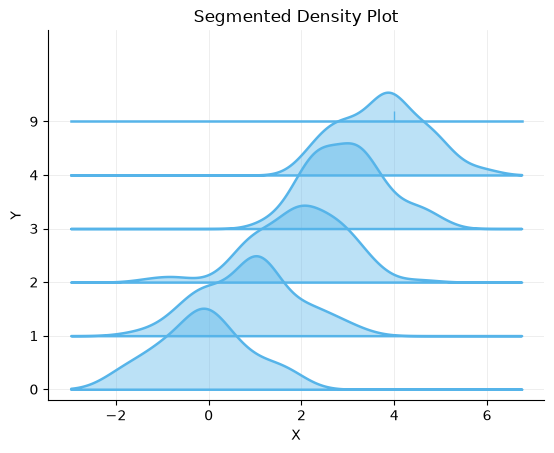

In [8]:
ax = plt.gca()
make_segmented_density(
    np.append(values, 4.0),   # one extra observation ...
    np.append(groups, 9),     # ... at a level of its own
    ax,
)
plt.show()

## 5. Overlay behavior — mimicking two `.plot()` calls

No color arguments here either: with `color` omitted, each batch takes the next hue
from the active style sheet's cycle automatically (the same cycle
`get_next_color(ax)` reads in the final integration, where `.plot()` passes the color
in). A second segmented density plot on the same axes lands its ridges on the same baselines
(levels are matched by value; levels new to the axes would get new baselines), comes
out in the next Okabe-Ito hue, and a legend appears automatically in the top right,
auto-named "Variable 1", "Variable 2", ... A single segmented density plot gets no legend.

Each batch is scaled to its own tallest peak, so overlays compare *shapes*, not
absolute density values.

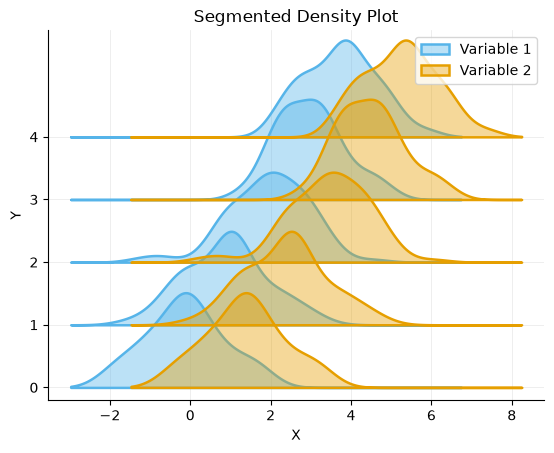

In [9]:
ax = plt.gca()
make_segmented_density(values, groups, ax)        # sky blue, automatically
make_segmented_density(values + 1.5, groups, ax)  # orange, automatically; legend appears
plt.show()

### Custom legend labels

`label=` overrides the automatic "Variable k" names.

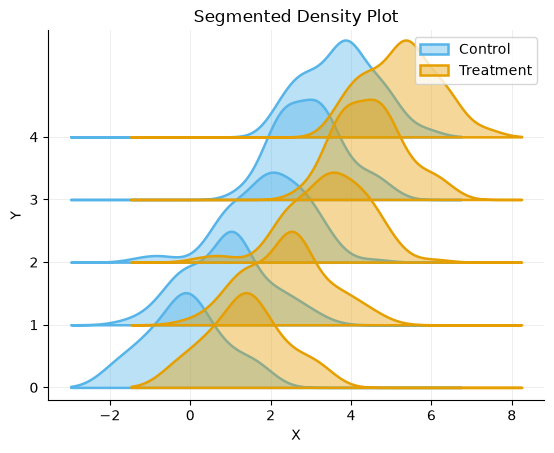

In [10]:
ax = plt.gca()
make_segmented_density(values, groups, ax, label="Control")
make_segmented_density(values + 1.5, groups, ax, label="Treatment")
plt.show()

## 6. With real symbulate simulation data

A joint discrete × continuous pair: `X` counts successes (Binomial), and `Y` is
Normal with mean `X`, so the ridges shift right as the level climbs. This is exactly
the configuration where the lookup table offers the segmented density as an alternative.

Simulation output arrives as one float array, so the discrete column is cast to int
here to steer the dtype-based detection — at integration, `classify_data` makes this
call instead.

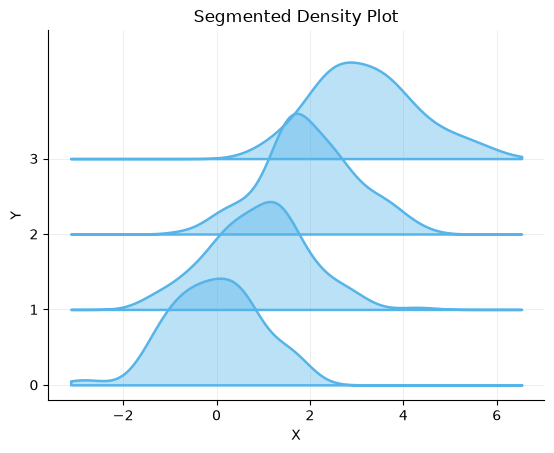

In [11]:
from symbulate import RV, Binomial, Normal

P = Binomial(3, 0.5) * Normal(0, 1)
X = RV(P, lambda outcome: outcome[0])               # discrete: 0, 1, 2, 3
Y = RV(P, lambda outcome: outcome[0] + outcome[1])  # continuous, mean = X
sims = (X & Y).sim(400)

arr = np.asarray(sims.results)
x_levels = arr[:, 0].astype(int)  # cast so the draft's dtype detection sees discrete
y_values = arr[:, 1]

ax = plt.gca()
make_segmented_density(y_values, x_levels, ax)  # discrete on y: classic look
plt.show()

### String levels work too

Any non-float dtype counts as discrete, including strings. Levels are ordered the way
`np.unique` sorts them — alphabetically for strings — the same behavior as the
segmented rug.

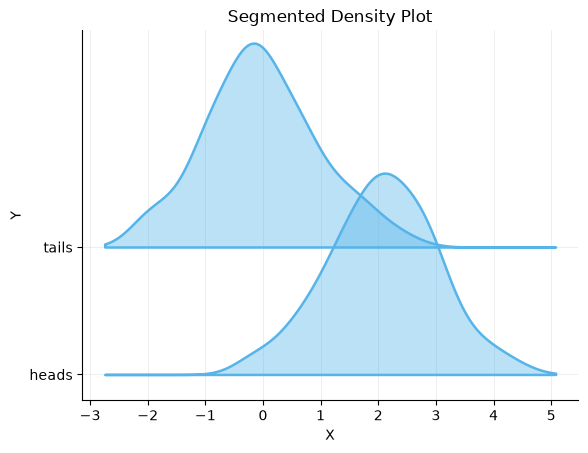

In [12]:
labels = np.where(rng.integers(0, 2, 300) == 1, "heads", "tails")
outcomes = rng.normal(0, 1, 300) + (labels == "heads") * 2

ax = plt.gca()
make_segmented_density(outcomes, labels, ax)
plt.show()

## 7. A process over time — one ridge per time point

The Phase 5 use case: for a discrete-time continuous-state process, a segmented density plot with
one ridge per time point shows how the process's distribution spreads or drifts.
Standard Brownian motion has B(t) ~ Normal(0, √t), so the ridges should widen — and,
because all ridges share one density scale, flatten — as t grows.

(Each time point is simulated independently here, so the ridges show the marginal
distribution at each time, which is all a segmented density plot displays anyway.)

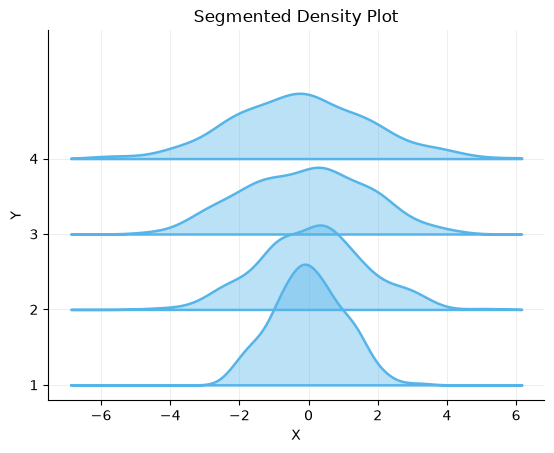

In [13]:
from symbulate import BrownianMotion

B = BrownianMotion()
times = [1, 2, 3, 4]
bm_values = np.concatenate([np.asarray(B[t].sim(300).results) for t in times])
bm_times = np.repeat(times, 300)  # int dtype -> auto-detected discrete

ax = plt.gca()
make_segmented_density(bm_values, bm_times, ax)
plt.show()  # time runs up the y-axis; distributions widen and flatten

### Non-integer time points — the `discrete_x=` / `discrete_y=` overrides

Observing the process at times like 0.5 gives float level values, which the dtype
detection reads as continuous. `discrete_y=True` overrides it: "treat y as the
grouping variable even though it's stored as floats." (At integration,
`classify_data` handles this — floats with few repeated values classify as
discrete-ish.)

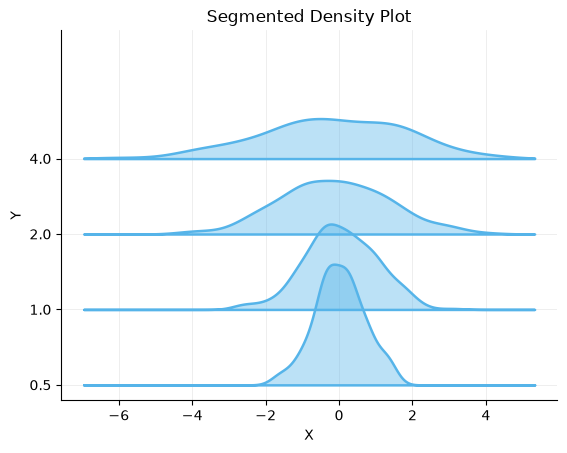

In [14]:
times = [0.5, 1.0, 2.0, 4.0]
bm_values = np.concatenate([np.asarray(B[t].sim(300).results) for t in times])
bm_times = np.repeat(times, 300)  # float dtype -> looks continuous

ax = plt.gca()
make_segmented_density(bm_values, bm_times, ax, discrete_y=True)
plt.show()

## 8. Only for mixed data

A segmented density plot needs exactly one discrete and one continuous variable. Two continuous
variables (or two discrete) raise a student-friendly error pointing to the right plot
type — scatter for two continuous, tile or jittered scatter for two discrete.

In [15]:
# Two continuous variables -> not a segmented density plot; raises a helpful error.
try:
    make_segmented_density(values, rng.normal(0, 1, 400), plt.gca())
except ValueError as e:
    print(f"ValueError: {e}")

# Two discrete variables -> same, pointing at tile / jittered scatter.
try:
    make_segmented_density(groups, groups, plt.gca())
except ValueError as e:
    print(f"ValueError: {e}")
plt.close("all")  # nothing meaningful was drawn; discard the empty figure

ValueError: A segmented density plot needs one discrete variable and one continuous variable, but both of yours look continuous. Try a scatter plot for two continuous variables.
ValueError: A segmented density plot needs one discrete variable and one continuous variable, but both of yours look discrete. Try a tile plot or a scatter plot with jitter for two discrete variables.


## Verification checklist

- [ ] One ridge per discrete level, stacked along the discrete axis with a gentle
  overlap; lower ridges drawn in front
- [ ] Translucent fill under a fully opaque outline (outline stays readable where
  ridges overlap)
- [ ] All ridges in one call share a single density scale — peak heights comparable
  across levels; tallest peak ≈ 1.6 baseline spacings
- [ ] Baselines sit at the discrete-axis ticks, labeled with the level values;
  headroom above the top baseline
- [ ] Section 2: orientation flips when x is the discrete variable (vertical ridges,
  stacked horizontally), mirroring the segmented rug / mixed tile plots
- [ ] `bandwidth=` changes every ridge's smoothness; `alpha=` changes only the fill
- [ ] Section 4: a sparse level keeps its baseline, shows tick marks, and prints a
  note that says what happened and how to fix it (simulate more draws)
- [ ] With no `color` argument, the first batch on the axes is Okabe-Ito sky blue and
  a second call automatically advances to orange (same cycle as `get_next_color`)
- [ ] An explicit `color=` still overrides the automatic one
- [ ] A single segmented density plot has no legend; legend appears in the top right on the second
  overlaid batch, auto-named "Variable 1", "Variable 2", ...
- [ ] Overlaid batches land on the same baselines, in distinct Okabe-Ito hues
- [ ] `label=` overrides the automatic legend names
- [ ] Works on real `.sim()` output (joint RV and BrownianMotion time points), not
  just numpy arrays
- [ ] String levels work; level order is `np.unique`'s (alphabetical for strings)
- [ ] Section 7: Brownian motion ridges widen and flatten as t grows
- [ ] `discrete_x=` / `discrete_y=` override the dtype-based detection (float time
  points)
- [ ] Two continuous or two discrete variables raise the friendly ValueError naming
  the right plot type
- [ ] Light reference grid behind the ridges on both axes (drawn below the ridges,
  never over them); one gridline per discrete level extends the baselines
- [ ] Axis labels "X"/"Y", title "Segmented Density Plot"